In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [38]:
from langgraph.graph import START, END, StateGraph
from langchain_groq import ChatGroq
from pydantic import BaseModel
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [27]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [28]:
class MailState(BaseModel):
    query: str = ""
    draft: str = ""
    human_feedback: str = ""
    final_response: str = ""

In [57]:
def DraftEmail(state: MailState) -> MailState:
    if state.human_feedback:
        draft = llm.invoke(f"""
                           Rewrite the draft email for {state.query},
                           You have generated a draft email: {state.draft},
                           Human feedback to apply: {state.human_feedback}
                           """).content
    else:
        draft = llm.invoke(state.query).content
    
    state.draft = draft
    return state

def HumanFeedback(state: MailState) -> MailState:
    feedback = interrupt({
        "draft_email": state.draft,
        "question": "Do you want to continue or rewrite the mail?" 
    })
    
    fb = (feedback or "").strip().lower()
    if fb in ("approved","ok","yes"):
        state.human_feedback = ""
        return state
    else:
        state.human_feedback = feedback
        return state
    
def FinalEmail(state: MailState) -> MailState:
    if state.human_feedback:
        state.final_response = state.human_feedback
        return state
    else:
        print("Email sent successfully!")
        state.final_response = "Email sent successfully!"
        return state
    
def ConditionRouting(state: MailState) -> Literal["DraftEmail", "FinalEmail"]:
    if state.human_feedback:
        return "DraftEmail"
    return "FinalEmail"

In [58]:
graph_builder = StateGraph(MailState)
graph_builder.add_node("DraftEmail", DraftEmail)
graph_builder.add_node("HumanFeedback", HumanFeedback)
graph_builder.add_node("FinalEmail", FinalEmail)

graph_builder.add_edge(START, "DraftEmail")
graph_builder.add_edge("DraftEmail", "HumanFeedback")
graph_builder.add_conditional_edges("HumanFeedback", ConditionRouting)
graph_builder.add_edge("FinalEmail", END)

graph = graph_builder.compile(checkpointer=InMemorySaver())

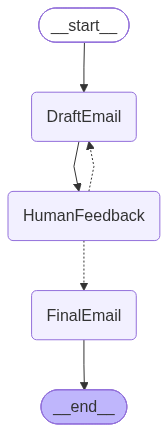

In [59]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [60]:
config = {"configurable": {"thread_id": "1"}}

In [61]:
res = graph.invoke({"query":"I want to send an email for medical leave for 2 days. Date will be from 1st to 2nd April 2026."}, config=config)

In [62]:
print(res["draft"])

**Subject:** Request for Medical Leave – 1 – 2 April 2026  

Dear [Manager’s Name],

I am writing to formally request medical leave for two days, from **Monday, 1 April 2026** to **Tuesday, 2 April 2026**. A doctor’s appointment and subsequent recovery period require my absence during this time.

I have ensured that all urgent tasks are either completed or delegated to [Colleague’s Name] so that our current projects remain on schedule. I will be reachable via email for any critical questions and will check my messages periodically.

Please let me know if you need a medical certificate or any additional documentation. I appreciate your understanding and approval of this leave.

Thank you for your consideration.

Kind regards,  
[Your Full Name]  
[Your Job Title]  
[Your Department]  
[Phone Number]  

---  

Feel free to adjust the tone or add specifics about your role and projects as needed.


In [65]:
res = graph.invoke(Command(resume="Replace the leave date to 4th to 8th April 2026. And remove the placeholders and just say Thank You."), config=config)
print(res["draft"])

**Subject:** Request for Medical Leave – 4 – 8 April 2026  

Dear [Manager’s Name],

I am writing to request medical leave for five days, from Thursday, 4 April 2026 to Monday, 8 April 2026. A doctor’s appointment and the necessary recovery period require my absence during this time.

I have arranged for all urgent tasks to be completed or delegated so that our current projects remain on schedule. I will remain reachable via email for any critical questions and will check my messages periodically.

Please let me know if you need a medical certificate or any additional documentation.

Thank You.


In [66]:
res = graph.invoke(Command(resume="yes"), config=config)

Email sent successfully!
